# Limpeza e Tratamento dos Dados

### 1. Setup (Bibliotecas)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("Bibliotecas carregadas")

Bibliotecas carregadas


### 2. Carregar Ficheiros

In [2]:
# Upload
from google.colab import files
uploaded = files.upload()

Saving richmond.csv to richmond (7).csv
Saving philadelphia.csv to philadelphia (7).csv
Saving lancaster.csv to lancaster (7).csv
Saving baltimore.csv to baltimore (7).csv


In [3]:
# Ler Dados
baltimore = pd.read_csv("baltimore.csv")
lancaster = pd.read_csv("lancaster.csv")
philadelphia = pd.read_csv("philadelphia.csv")
richmond = pd.read_csv("richmond.csv")

print("Dados carregados")

Dados carregados


### 3. Explorar os Dados

In [4]:
missing = pd.DataFrame({
    "Baltimore": baltimore.isnull().sum(),
    "Lancaster": lancaster.isnull().sum(),
    "Philadelphia": philadelphia.isnull().sum(),
    "Richmond": richmond.isnull().sum()
})

missing

,Baltimore,Lancaster,Philadelphia,Richmond
Date,0,0,0,0
Num_Employees,0,0,0,0
Num_Customers,0,0,0,0
Pct_On_Sale,1,1,1,1
TouristEvent,0,0,0,0
Sales,0,0,0,0


In [5]:
for name, df in [
    ("Baltimore", baltimore),
    ("Philadelphia", philadelphia),
    ("Richmond", richmond),
    ("Lancaster", lancaster)
]:
    print(f"\n{name}:")
    display(df[df.isnull().any(axis=1)])


Baltimore:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,6,0,NaN,No,21268



Philadelphia:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,15,0,NaN,No,51806



Richmond:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,5,0,NaN,No,15178



Lancaster:


,Date,Num_Employees,Num_Customers,Pct_On_Sale,TouristEvent,Sales
658,2014-04-20,7,0,NaN,No,30812


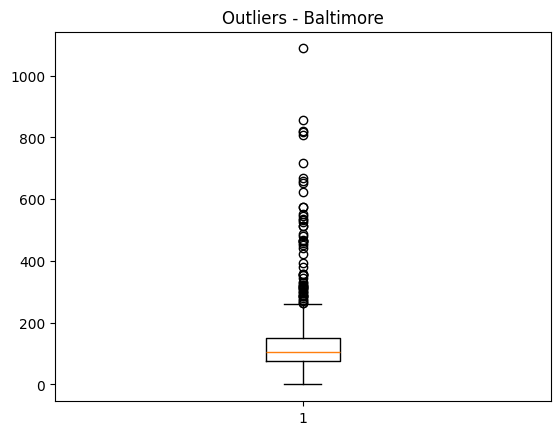


Baltimore - Intervalo original:
Min: 0
Max: 1088


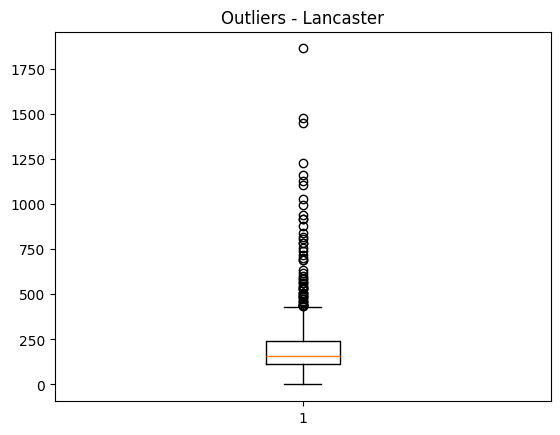


Lancaster - Intervalo original:
Min: 0
Max: 1862


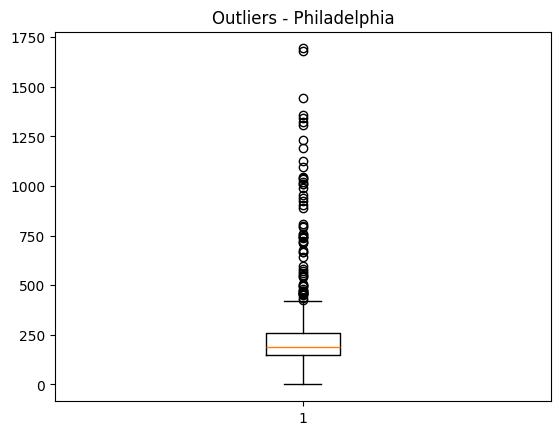


Philadelphia - Intervalo original:
Min: 0
Max: 1693


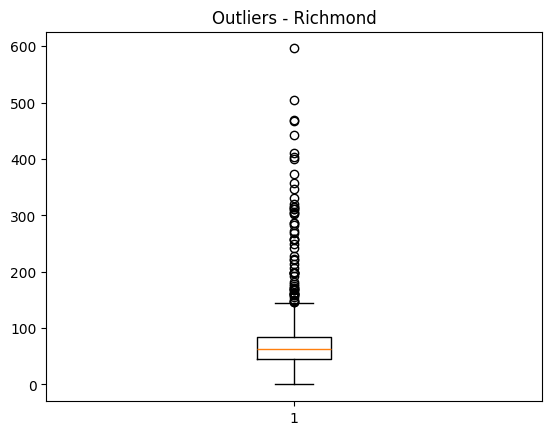


Richmond - Intervalo original:
Min: 0
Max: 596


In [6]:
for name, df in {
    "Baltimore": baltimore,
    "Lancaster": lancaster,
    "Philadelphia": philadelphia,
    "Richmond": richmond
}.items():

    plt.figure()
    plt.boxplot(df['Num_Customers'])
    plt.title(f"Outliers - {name}")
    plt.show()

    print(f"\n{name} - Intervalo original:")
    print("Min:", df['Num_Customers'].min())
    print("Max:", df['Num_Customers'].max())

In [7]:
for name, df in {
    "Baltimore": baltimore,
    "Lancaster": lancaster,
    "Philadelphia": philadelphia,
    "Richmond": richmond
}.items():

    q_low = df['Num_Customers'].quantile(0.01)
    q_high = df['Num_Customers'].quantile(0.99)

    outliers = df[(df['Num_Customers'] < q_low) | (df['Num_Customers'] > q_high)]

    print(f"{name}: {len(outliers)} outliers")

Baltimore: 16 outliers
Lancaster: 16 outliers
Philadelphia: 16 outliers
Richmond: 16 outliers


In [9]:
def validate_data(df, name="Dataset"):

    print(f"\nValidação - {name}")

    # Condições de erro
    invalid_rows = df[
        (df['Num_Customers'] < 0) |
        (df['Num_Employees'] < 0) |
        (df['Pct_On_Sale'] < 0) |
        (df['Pct_On_Sale'] > 30) |
        (df['Sales'] < 0) |
        (df['Date'].isnull())
    ]

    if invalid_rows.empty:
        print("✅ Sem valores inválidos")
    else:
        print("❌ Linhas com valores inválidos:")
        display(invalid_rows)

In [10]:
validate_data(baltimore, "Baltimore")
validate_data(lancaster, "Lancaster")
validate_data(philadelphia, "Philadelphia")
validate_data(richmond, "Richmond")


Validação - Baltimore
✅ Sem valores inválidos

Validação - Lancaster
✅ Sem valores inválidos

Validação - Philadelphia
✅ Sem valores inválidos

Validação - Richmond
✅ Sem valores inválidos


### 4. Limpeza e Tratamento dos Dados

In [11]:
def clean_data(df):

    # 1. Datas
    df['Date'] = pd.to_datetime(df['Date'])
    df = df.sort_values('Date')

    # 2. Valores em falta
    df['Num_Customers'] = df['Num_Customers'].interpolate()
    df = df.fillna(method='ffill')

    # 3. Outliers (clipping) 1-99% para reduzir impacto de valores extremos sem remover dados reais
    q_low = df['Num_Customers'].quantile(0.01)
    q_high = df['Num_Customers'].quantile(0.99)
    df['Num_Customers'] = df['Num_Customers'].clip(q_low, q_high)

    # 4. Variáveis categóricas
    df['TouristEvent'] = df['TouristEvent'].map({'Yes':1, 'No':0})

    return df

In [12]:
# Aplicar Função a todas as lojas
baltimore = clean_data(baltimore)
lancaster = clean_data(lancaster)
philadelphia = clean_data(philadelphia)
richmond = clean_data(richmond)

/tmp/ipykernel_28601/2593118901.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_28601/2593118901.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_28601/2593118901.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')
/tmp/ipykernel_28601/2593118901.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


### 5. Verificar Resultados

In [13]:
missing = pd.DataFrame({
    "Baltimore": baltimore.isnull().sum(),
    "Lancaster": lancaster.isnull().sum(),
    "Philadelphia": philadelphia.isnull().sum(),
    "Richmond": richmond.isnull().sum()
})

missing

,Baltimore,Lancaster,Philadelphia,Richmond
Date,0,0,0,0
Num_Employees,0,0,0,0
Num_Customers,0,0,0,0
Pct_On_Sale,0,0,0,0
TouristEvent,0,0,0,0
Sales,0,0,0,0


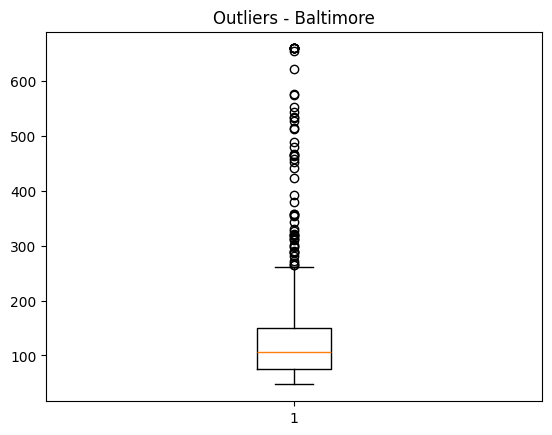


Baltimore - Novo Intervalo:
Min: 47.13
Max: 659.22


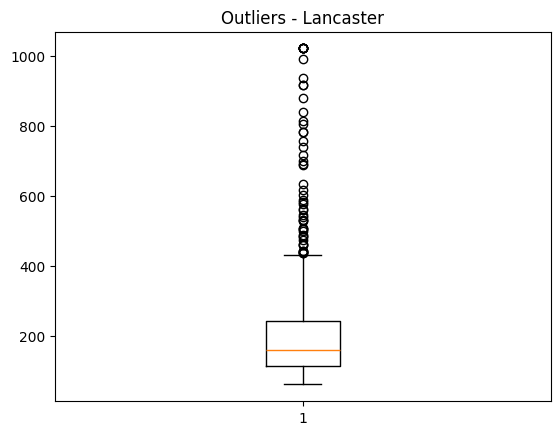


Lancaster - Novo Intervalo:
Min: 60.13
Max: 1021.7100000000002


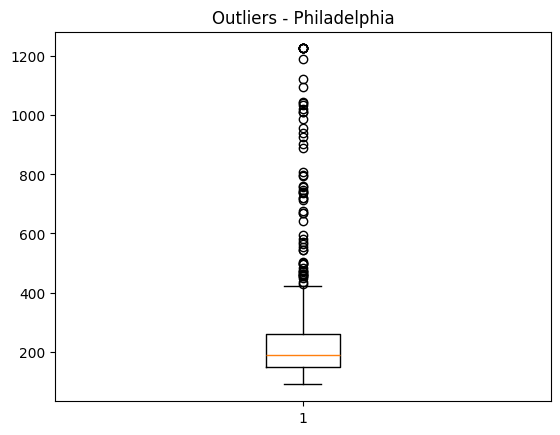


Philadelphia - Novo Intervalo:
Min: 89.39
Max: 1225.67


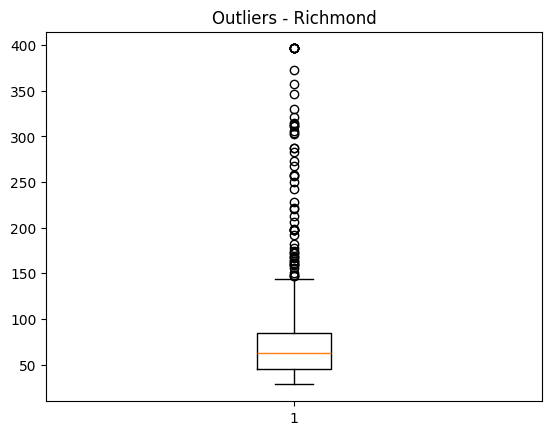


Richmond - Novo Intervalo:
Min: 28.13
Max: 396.4900000000001


In [14]:
for name, df in {
    "Baltimore": baltimore,
    "Lancaster": lancaster,
    "Philadelphia": philadelphia,
    "Richmond": richmond
}.items():

    plt.figure()
    plt.boxplot(df['Num_Customers'])
    plt.title(f"Outliers - {name}")
    plt.show()

    print(f"\n{name} - Novo Intervalo:")
    print("Min:", df['Num_Customers'].min())
    print("Max:", df['Num_Customers'].max())